# Stock Price Prediction using HMM, LSTM, ARIMA, and RNN

In this notebook, we will predict stock prices using various methods including Hidden Markov Model (HMM), Long Short-Term Memory (LSTM), AutoRegressive Integrated Moving Average (ARIMA), and Recurrent Neural Network (RNN). We will compare the performance of these models using various error metrics.


In [1]:
# Import necessary libraries for data manipulation, model building, and evaluation

from hmmlearn import hmm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

## Load and Prepare Data

In this section, we load the NIFTY 50 data and preprocess it for modeling.


In [ ]:
data_csv = pd.read_csv(r"NIFTY 50.csv")

data = data_csv[data_csv.columns[0:5]]
data = data[:5348]

# Convert 'Date' column to datetime type
data['Date'] = pd.to_datetime(data['Date'])

# Set the 'Date' column as the index
data.set_index('Date', inplace=True)

# Resample the data to monthly frequency
obs = data.resample('M').agg({'Open': 'first','High': 'max','Low': 'min','Close': 'last'})

# Reset the index to have 'Date' as a column again
obs = obs.reset_index()

# Print the monthly data
print(obs)

data = obs[:162]
print(data)

In [ ]:
# Yahoo Finance ticker for Novo Nordisk (US ADR)
ticker = "NVO"

# Download historical data
dataN = yf.download(ticker, start="2020-01-01", end="2026-01-01")
dataN = dataN.reset_index()[["Date", "Open", "High", "Low", "Close"]]
dataN.columns = dataN.columns.droplevel(1)
dataN.columns.name = None
# Convert 'Date' column to datetime type
dataN['Date'] = pd.to_datetime(dataN['Date'])

# Set the 'Date' column as the index
dataN.set_index('Date', inplace=True)

# Resample the data to monthly frequency
obs = dataN.resample('M').agg({'Open': 'first','High': 'max','Low': 'min','Close': 'last'})

# Reset the index to have 'Date' as a column again
obs = obs.reset_index()

# --- Convert dates to just YYYY-MM-DD ---
obs['Date'] = obs['Date'].dt.date  # <-- this removes the timestamp

# Print the monthly data
print(obs)
cutoff = 40
data = obs[:40]
dates = obs['Date'][cutoff:]
print(data)

In [4]:
from modelFuncs import dataExtracterMonths

In [11]:
# Print the monthly data
obs = dataExtracterMonths('NVO', '2002-01-01', '2026-01-01')

[*********************100%***********************]  1 of 1 completed

The dataset has observations across 288 months



/Users/sagar1/Desktop/Github/AppStat2/Sagar/modelFuncs.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  obs = data.resample('M').agg({'Open': 'first','High': 'max','Low': 'min','Close': 'last'})


## Hidden Markov Model (HMM)

We will implement the HMM to predict future stock prices.

In [12]:
cutoff = 100
data = obs[:cutoff]
dates = obs['Date'][cutoff:]
data = data[data.columns[1:5]]
obs = obs[obs.columns[1:5]]

In [13]:
print(obs)
print(data)

          Open       High        Low      Close
0     1.307568   1.307891   1.074466   1.154211
1     1.165511   1.279157   1.149368   1.260754
2     1.239445   1.313409   1.194569   1.290916
3     1.299066   1.323515   0.920593   0.951888
4     0.993288   1.124661   0.993288   1.043816
..         ...        ...        ...        ...
283  47.732133  58.340000  44.548012  56.459999
284  56.720001  62.320000  52.720001  55.490002
285  56.009998  60.900002  48.490002  49.459999
286  49.410000  50.430000  43.080002  49.349998
287  48.930000  53.630001  46.080002  50.880001

[288 rows x 4 columns]
        Open      High       Low     Close
0   1.307568  1.307891  1.074466  1.154211
1   1.165511  1.279157  1.149368  1.260754
2   1.239445  1.313409  1.194569  1.290916
3   1.299066  1.323515  0.920593  0.951888
4   0.993288  1.124661  0.993288  1.043816
..       ...       ...       ...       ...
95  4.987661  5.106572  4.633119  4.657925
96  4.756407  5.116056  4.676890  4.919088
97  5.070097 

In [ ]:

# Calculate number of rows and set training window
T = data.shape[0]
print("T= ", T)

# Define the size of the training window
predict_size = len(obs) - len(data) # Data points to predict
window_size = 100 # Window size
hmm_price = []

temp_T = T
first_time = True

# Sliding window approach to predict future prices
while T < temp_T + predict_size:

    # Train HMM on data from T-window_size+1 to T
    train_data = obs.iloc[T-window_size:T]
    train_data = train_data.dropna()

    # Set the random seed
    np.random.seed(123)

    if(first_time):
      first_time = False
      model = hmm.GaussianHMM(n_components=5)
    else:
      old_model= model
      model = hmm.GaussianHMM(n_components=5, init_params="c")
      model.startprob_ = old_model.startprob_
      model.transmat_ = old_model.transmat_
      model.means_ = old_model.means_

    model.fit(train_data)

    # Calculate original likelihood
    original_likelihood = model.score(train_data)

    # Loop to find new likelihood
    t=T
    min_diff = float('inf')
    min_t = T
    min_likelihood = original_likelihood
    while t-window_size>  0:
        t = t-1

        train_data = obs.iloc[t-window_size:t]
        new_likelihood = model.score(train_data)
        if (abs(new_likelihood - original_likelihood))< min_diff:  # Threshold for comparison by choosing that new_likelihood which is minimum
            min_diff = abs(new_likelihood - original_likelihood)
            min_t = t
            min_likelihood = new_likelihood

    # Calculate the predicted close price
    close_price = obs['Close'][T-1] + ((obs['Close'][min_t + 1] - obs['Close'][min_t]) * np.sign(original_likelihood - min_likelihood))

    hmm_price.append(close_price)
    T=T+1

# Print the calculated prices
print("HMM Prices: ")
print(hmm_price)

# Plot the predicted and observed prices
close = []
truncated_obs = obs.iloc[T-predict_size:T]

for i in truncated_obs['Close']:
  close.append(i)

# plt.plot(hmm_price,marker='.', label = "HMM Predicted Price")
# plt.plot(close,marker = '.', label= "Observed Price")
# plt.ylabel("Close Price")
# plt.legend()
# plt.show()

T=  100


Model is not converging.  Current: -841.8933862291697 is not greater than -841.8933754006082. Delta is -1.0828561471498688e-05


HMM Prices: 
[np.float64(6.0977020263671875), np.float64(5.393608093261719), np.float64(5.645387172698975), np.float64(6.017488479614258), np.float64(6.04719877243042), np.float64(6.3591389656066895), np.float64(8.183252811431885), np.float64(6.407418251037598), np.float64(8.319164276123047), np.float64(7.4256815910339355), np.float64(8.430578708648682), np.float64(8.462852954864502), np.float64(8.625669002532959), np.float64(9.553345680236816), np.float64(9.339271545410156), np.float64(10.355358123779297), np.float64(8.577961921691895), np.float64(8.039764404296875), np.float64(7.5015668869018555), np.float64(8.688008308410645), np.float64(8.983490943908691), np.float64(10.57772445678711), np.float64(10.639192581176758), np.float64(11.276577949523926), np.float64(12.291332244873047), np.float64(11.147720336914062), np.float64(11.85336971282959), np.float64(11.147720336914062), np.float64(11.344842910766602), np.float64(11.913963317871094), np.float64(12.09727668762207), np.float64(12.

## Plot Predictions

Now, we plot the predictions from all models alongside the actual observed prices.


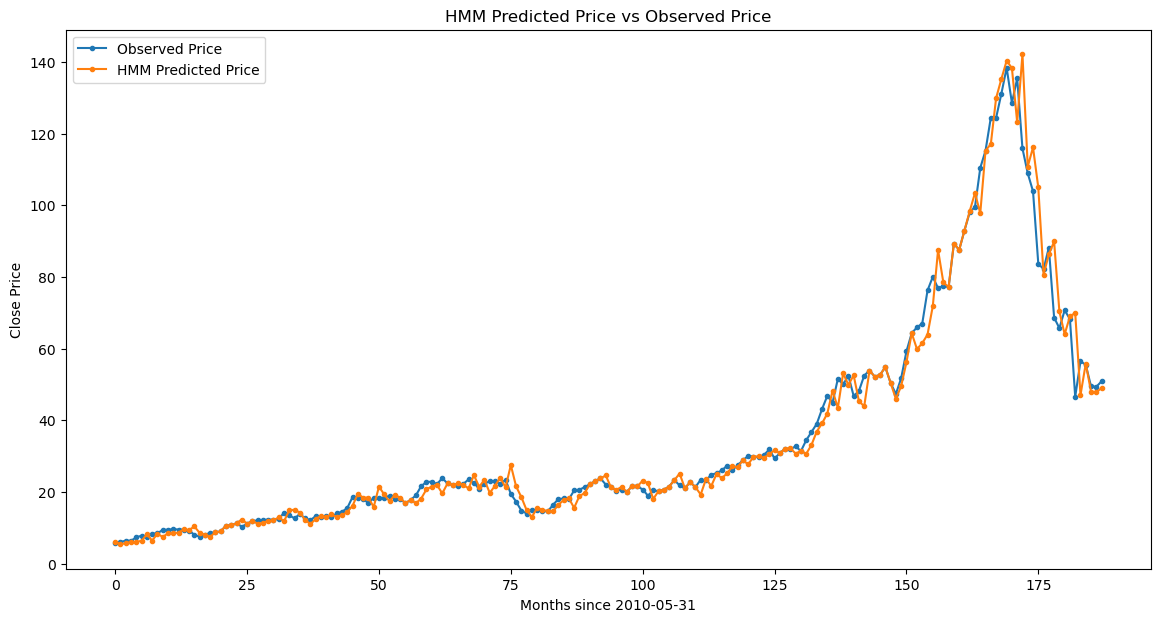

In [15]:
fig, ax = plt.subplots(figsize=(14, 7))

# Plot actual prices for the corresponding period
ax.plot(close, marker='.', label='Observed Price')
ax.plot(hmm_price, marker='.', label='HMM Predicted Price')
ax.set_ylabel("Close Price")
ax.set_xlabel(f"Months since {dates[cutoff]}")
ax.legend();
ax.set_title("HMM Predicted Price vs Observed Price");

## Model Evalution

In [16]:
from evaluationFuncs import ape, aae, arpe, rmse

In [17]:
# Convert lists to numpy arrays
close = np.array(close)
hmm_price = np.array(hmm_price)

ape_hmm = ape(close, hmm_price)
aae_hmm = aae(close, hmm_price)
arpe_hmm = arpe(close, hmm_price)
rmse_hmm = rmse(close, hmm_price)
print("Absolute Percentage Error for HMM: ", ape_hmm)
print("Average Absolute Error for HMM: ", aae_hmm)
print("Average Relative Percentage Error for HMM: ", arpe_hmm)
print("Root Mean Squared Error for HMM: ", rmse_hmm)

Absolute Percentage Error for HMM:  0.0682658975085061
Average Absolute Error for HMM:  2.3829344054485895
Average Relative Percentage Error for HMM:  0.012675183007705263
Root Mean Squared Error for HMM:  4.659449201717999
